In [1]:
# =============================================================================
# Auckland urban drainage network (UDN) -- preprocessing
# -----------------------------------------------------------------------------
# Builds the two canonical tables consumed by the reconstruction notebooks:
#   df_pipe : pipe_id, material, diameter
#   df_node : node_id, x, y, rimElevation, invertElevation
# from the raw wastewater/stormwater CSV exports.
# =============================================================================
import pandas as pd
import numpy as np
import function
import importlib

importlib.reload(function)

from function import *

In [2]:
# ── Pipe table ───────────────────────────────────────────────────────────
# Load the wastewater and stormwater pipe exports. Each source uses its own
# column names, so both are subset and renamed to the canonical schema
# separately before being concatenated in the next cell.
df_waste = pd.read_csv("../data/Auckland/Wastewater/Wastewater_Pipe.csv")
df_storm = pd.read_csv("../data/Auckland/Stormwater/Stormwater_Pipe.csv")

df_storm = df_storm[["GIS ID", "Pipe Material","Asset Diameter (mm)"]]
df_waste = df_waste[["GIS_ID", "MATERIAL", "NOM_DIA_MM"]]

df_storm = df_storm.rename(columns={"GIS ID": "pipe_id", "Pipe Material": "material", "Asset Diameter (mm)": "diameter"})
df_waste = df_waste.rename(columns={"GIS_ID": "pipe_id", "MATERIAL": "material", "NOM_DIA_MM": "diameter"})

C:\Users\sebas\AppData\Local\Temp\ipykernel_12852\2734038910.py:5: DtypeWarning: Columns (3,10,36,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_waste = pd.read_csv("../data/Auckland/Wastewater/Wastewater_Pipe.csv")
C:\Users\sebas\AppData\Local\Temp\ipykernel_12852\2734038910.py:6: DtypeWarning: Columns (0,6,8,10,16,17,22,29,39,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df_storm = pd.read_csv("../data/Auckland/Stormwater/Stormwater_Pipe.csv")


In [3]:
# Concatenate both networks into a single pipe table.
df_pipe = pd.concat([df_waste, df_storm]).reset_index(drop = True)

In [4]:
# Sanity check: how many pipes are missing an id? (fixed in the next cell)
df_pipe[df_pipe["pipe_id"].isna()]

,pipe_id,material,diameter
643022,NaN,CONC,1200.0
643529,NaN,CONC,300.0
784036,NaN,CONC,450.0
785041,NaN,CONC,600.0
785494,NaN,CONC,1200.0
...,...,...,...
855338,NaN,PYVN,150.0
855339,NaN,CONC,225.0
855340,NaN,PYVN,150.0
855341,NaN,PYVN,150.0


In [5]:
# Rather than drop these rows, generate a synthetic id from the row index
# so the pipe (and its material/diameter) is kept.
for idx, row in (df_pipe[df_pipe["pipe_id"].isna()]).iterrows():
    df_pipe.loc[idx, "pipe_id"] = f"added_{idx}"

In [6]:
# Sanity check: any exact duplicate rows (same id, material, and diameter
# all at once -- most likely a repeated export line)?
df_pipe[df_pipe[["pipe_id", "material", "diameter"]].duplicated()]

,pipe_id,material,diameter
851408,PIPE2642362,PYVN,150.0
851752,{C1B105D7-B2E0-4645-BA54-F34731AD699E},CONC,225.0
852399,PIPE2666434,CONC,225.0
852412,PIPE2666434,CONC,225.0
852414,PIPE2666434,CONC,375.0
...,...,...,...
855304,{BA9C1D92-B55F-40A4-8BAA-8609512ADFD4},CONC,450.0
855310,{81F90357-0C02-436A-BD85-08A7DED4807B},PYTH,250.0
855315,{B3493B15-1399-4D5F-9C92-681D17827859},PYTH,225.0
855319,{EBB17682-746A-4259-8D67-CCC1081EACF9},CONC,600.0


In [7]:
# Drop exact duplicate rows found above.
df_pipe = df_pipe.drop_duplicates(subset=["pipe_id", "material", "diameter"]).reset_index(drop = True)

In [8]:
# Sanity check: any remaining pipe_id collisions, now that exact duplicates
# are gone -- i.e. the same id shared by rows with different material and/or
# diameter, which points to distinct pipes rather than a repeated export
# line (fixed in the next cell).
df_pipe[df_pipe[["pipe_id"]].duplicated(keep = False)]

,pipe_id,material,diameter
849803,PIPE2611432,CONC,225.0
849894,PIPE2611432,CONC,300.0
850944,PIPE2635533,PYVN,150.0
850964,PIPE2635533,CONC,225.0
851702,PIPE,CONC,225.0
852395,PIPE2666044,CONC,900.0
852396,PIPE2666434,CONC,225.0
852397,PIPE2666434,CONC,375.0
852402,PIPE2666044,CONC,450.0
852403,PIPE2666434,CONC,675.0


In [9]:
# Every row sharing a colliding pipe_id is a genuine, distinct pipe (as
# confirmed above), so none should be dropped. Each is given a synthetic,
# row-index-based id instead -- the same scheme already used for missing
# ids above -- which keeps every pipe and its own material/diameter, at
# the cost of no longer tracing back to the original shared id.
for idx, row in (df_pipe[df_pipe["pipe_id"].duplicated(keep=False)]).iterrows():
    df_pipe.loc[idx, "pipe_id"] = f"added_{idx}"

In [10]:
# Diameter distribution, used to calibrate the upper bound applied below
# (manuscript Section 2.2.2 approach: inspect the percentiles rather than
# guess a cutoff).
print(df_pipe["diameter"].describe())
print("99 percentile =", np.quantile(df_pipe["diameter"].dropna(), 0.99))
print("99,9 percentile =", np.quantile(df_pipe["diameter"].dropna(), 0.999))

count    854343.000000
mean        206.333464
std         199.541176
min           0.000000
25%         100.000000
50%         150.000000
75%         225.000000
max        9000.000000
Name: diameter, dtype: float64
99 percentile = 1050.0
99,9 percentile = 2050.0


In [11]:
# Diameters at or below 0 or at/above 10,000 mm are treated as physically
# implausible for this network and set to NaN (the pipe itself is kept --
# only its diameter value is discarded, to be reconstructed later).
mask = (df_pipe["diameter"] <= 0.0) | (df_pipe["diameter"] >= 10000)
df_pipe.loc[mask, "diameter"] = np.nan

material
PVC-U    355450
CONC     264791
AC        77063
PYVN      48305
VC        46834
PE        24334
ABCM      10880
PYTH       7610
ERWR       5422
CI         3964
CLS        2588
PERF       2302
UNDEF       979
FITI        755
MS          291
DI          251
CCLS        204
BRCK        144
GRP         142
PYPR        133
SS          111
ALUM        108
OTHR         99
STEL         88
MASON        85
COIR         52
CAIR         44
FBGL         35
ELS          34
COST         32
PP           27
GAIR         19
FRP          18
ABS          18
ROCK         14
DUIR          5
PL            4
COPR          4
ALKA          4
Conc          1
CU            1
ALU           1
MASN          1
TIMB          1
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

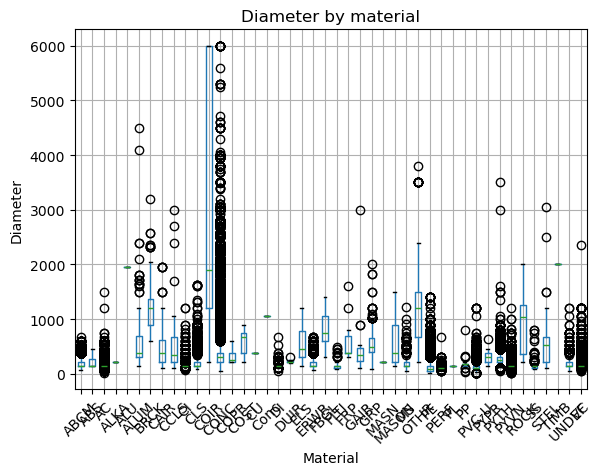

material
Plastic            436080
Concrete           265022
Asbestos-cement     87943
Earthenware         52270
Metal                7679
Undetermined         6192
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

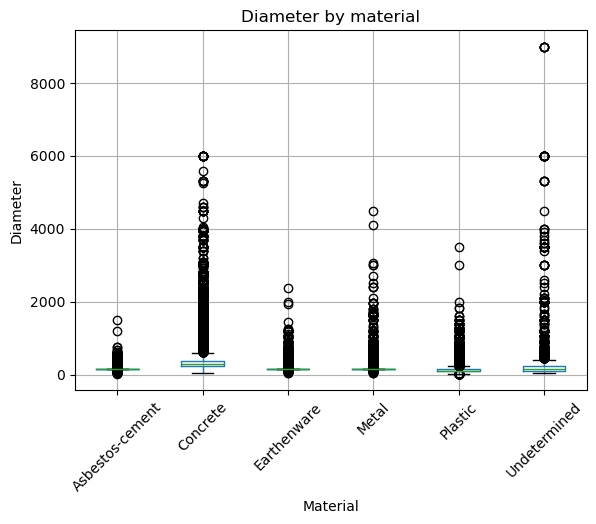

In [12]:
# ── Material category grouping (manuscript Section 2.2.4) ─────────────────
# Auckland's own raw material vocabulary. Unlike the other three networks,
# it includes a 7th class, Earthenware, for labels that do not fit the
# manuscript's original six-class scheme -- to be noted explicitly when
# reporting results for this network.
def map_material(mat):
    if mat in plastic:
        return "Plastic"
    elif mat in concrete:
        return "Concrete"
    elif mat in metal:
        return "Metal"
    elif mat in asbestos_cement:
        return "Asbestos-cement"
    elif mat in glass:
        return "Glass"
    elif mat in earthenware:
        return "Earthenware"
    else:
        return "Undetermined"

print(df_pipe["material"].value_counts())

boxplot_mat_dia(df_pipe)

plastic = ["PVC-U", "PE", "PP", "PYPR", "ABS", "GRP", "FRP", "FBGL", "PL", "ALKA", "PYVN", "PYTH"]
concrete = ["CONC", "Conc", "BRCK", "MASON", "MASN"]
metal = ["CI", "CAIR", "DI", "DUIR", "MS", "STEL", "SS", "ALUM", "ALU", "CU", "COPR", "CLS", "CCLS", "GAIR"]
asbestos_cement = ["AC", "ABCM"]
earthenware = ["VC", "ERWR", "ROCK"]
glass = []

df_pipe["material"] = df_pipe["material"].apply(map_material)

print(df_pipe["material"].value_counts())

boxplot_mat_dia(df_pipe)

In [13]:
# ── Node table ───────────────────────────────────────────────────────────
# Load the wastewater and stormwater manhole exports. The wastewater file
# is checked below for coverage across its candidate elevation columns:
# all five (LID_LEV, INV_LEV, INV_DEPTH, IL_NZVD16, LL_NZVD16) turn out to
# be 100% missing (191,027/191,027 NaN) -- wastewater manholes carry no
# elevation information at all in this export. IL_NZVD16/LL_NZVD16 are
# still selected and renamed to the canonical schema (invertElevation/
# rimElevation), but every
# wastewater rimElevation/invertElevation value will be NaN going into the
# reconstruction step. In practice, this means the spatial reconstruction
# for wastewater manholes has no known wastewater neighbour to anchor on
# at all -- it depends entirely on stormwater manholes falling within the
# search radius.
df_waste = pd.read_csv("../data/Auckland/Wastewater/Wastewater_Manhole.csv")
df_storm = pd.read_csv("../data/Auckland/Stormwater/Stormwater_Manhole.csv")

cols = ["LID_LEV", "INV_LEV", "INV_DEPTH", "IL_NZVD16", "LL_NZVD16"]
print(df_waste[cols].isna().sum())
print(df_waste[cols].notna().sum())

df_waste = df_waste[["OBJECTID", "X", "Y", "IL_NZVD16", "LL_NZVD16"]]
df_storm = df_storm[["OBJECTID", "x", "y", "Invert Level (m) NZVD2016", "Cover Level (m) NZVD2016"]]

df_storm = df_storm.rename(columns={"OBJECTID": "node_id", "Invert Level (m) NZVD2016": "invertElevation", "Cover Level (m) NZVD2016": "rimElevation"})
df_waste = df_waste.rename(columns={"OBJECTID": "node_id", "IL_NZVD16": "invertElevation", "LL_NZVD16": "rimElevation", "X": "x", "Y": "y"})

C:\Users\sebas\AppData\Local\Temp\ipykernel_12852\677060729.py:14: DtypeWarning: Columns (5,7,26,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df_waste = pd.read_csv("../data/Auckland/Wastewater/Wastewater_Manhole.csv")
C:\Users\sebas\AppData\Local\Temp\ipykernel_12852\677060729.py:15: DtypeWarning: Columns (6,14,17,20,21,25,26,28,33,37,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df_storm = pd.read_csv("../data/Auckland/Stormwater/Stormwater_Manhole.csv")


LID_LEV      191027
INV_LEV      191027
INV_DEPTH    191027
IL_NZVD16    191027
LL_NZVD16    191027
dtype: int64
LID_LEV      0
INV_LEV      0
INV_DEPTH    0
IL_NZVD16    0
LL_NZVD16    0
dtype: int64


In [14]:
# Generate a fresh sequential node id per source file (prefixed by network
# type), rather than relying on the raw OBJECTID. The two prefixes make
# collisions between the wastewater and stormwater tables structurally
# impossible, so no node_id collision check is needed for this network
# (unlike networks that keep the raw source id).
df_waste["node_id"] = "wastewater_manhole_" + pd.Series(np.arange(len(df_waste))).astype(str)
df_storm["node_id"] = "stormwater_manhole_" + pd.Series(np.arange(len(df_storm))).astype(str)

In [15]:
# Concatenate both networks into a single node table, now that both carry
# their final, collision-free node ids.
df_node = pd.concat([df_waste, df_storm]).reset_index(drop = True)

In [16]:
# Collapse coincident-location duplicates, keeping the first occurrence.
df_node = df_node[~df_node[["x", "y"]].duplicated(keep = "first")]

In [17]:
# ── Removal of physically impossible node-level values (Section 2.2.2) ────
# Elevations outside the admissible range for this network are discarded,
# and invert elevations exceeding the rim elevation at the same node are
# set to NaN as a hydraulically impossible configuration.
columns = [
    "invertElevation",
    "rimElevation",
]

nan_before = df_node[columns].isna().sum()

df_node["invertElevation"] = discardHeightImpossible(df_node, "invertElevation", -10, 700)
df_node["rimElevation"] = discardHeightImpossible(df_node, "rimElevation", -5, 700)

mask = df_node["invertElevation"] > df_node["rimElevation"]
df_node.loc[mask, "invertElevation"] = np.nan
df_node.loc[mask, "rimElevation"] = np.nan

nan_after = df_node[columns].isna().sum()

nan_diff = pd.DataFrame({
    "NaN_before": nan_before,
    "NaN_after": nan_after,
    "increase": nan_after - nan_before,
    "increase_%": ((nan_after - nan_before) / len(df_node) * 100).round(2)
})

print(nan_diff)

                 NaN_before  NaN_after  increase  increase_%
invertElevation      245470     245559        89        0.02
rimElevation         243221     243308        87        0.02


In [18]:
# ── Serialisation ───────────────────────────────────────────────────────
# Save the cleaned pipe and node tables to disk (pickle format) for the
# downstream reconstruction notebooks.
df_pipe.to_pickle("../data/Auckland/df_pipe_Auckland.pkl")
df_node.to_pickle("../data/Auckland/df_node_Auckland.pkl")